# Swiggy End-to-End Data Analytics & Business Intelligence

This notebook is the complete computational and analytical backbone for the Swiggy Data Analytics project, encompassing data loading, deep exploratory data analysis (Q1-Q14), statistical hypothesis testing, RFM segmentation, and multi-model churn prediction (without data leakage).

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import joblib
import os
import warnings
from scipy.stats import ttest_ind

from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

os.makedirs('Processed_Data', exist_ok=True)

## 2. Data Loading

In [2]:
try:
    users = pd.read_csv("Data/Users.csv")
    restaurants = pd.read_csv("Data/Restaurant.csv")
    orders = pd.read_csv("Data/Orders.csv")
    menu = pd.read_csv("Data/Menu.csv")
    food = pd.read_csv("Data/Food.csv")
except FileNotFoundError:
    users = pd.read_csv("Users.csv")
    restaurants = pd.read_csv("Restaurant.csv")
    orders = pd.read_csv("Orders.csv")
    menu = pd.read_csv("Menu.csv")
    food = pd.read_csv("Food.csv")

## 3. Data Understanding & Profiling

In [3]:
# Users Profiling
print("Users shape:", users.shape)
display(users.head(3))
display(users.isnull().sum())

# Restaurants Profiling
print("\nRestaurants shape:", restaurants.shape)
display(restaurants.head(3))
display(restaurants.isnull().sum())

# Orders Profiling
print("\nOrders shape:", orders.shape)
display(orders.head(3))
display(orders.isnull().sum())

# Menu & Food Profiling
print("\nMenu shape:", menu.shape)
print("Food shape:", food.shape)

Users shape: (100000, 6)


,User_id,Name,Age,Gender,Marital Status,Occupation
0,1,Claire Ferguson,20,Female,Single,Student
1,2,Jennifer Young,24,Female,Single,Student
2,3,Jermaine Roberson,22,Male,Single,Student


User_id           0
Name              0
Age               0
Gender            0
Marital Status    0
Occupation        0
dtype: int64


Restaurants shape: (148454, 7)


,Restaurant_id,Name,Country,City,Rating,Rating_count,Cuisine
0,567335,AB FOODS POINT,India,Abohar,--,Too Few Ratings,"Beverages,Pizzas"
1,531342,Janta Sweet House,India,Abohar,4.4,50+ ratings,"Sweets,Bakery"
2,158203,theka coffee desi,India,Abohar,3.8,100+ ratings,Beverages


Restaurant_id    0
Name             0
Country          0
City             0
Rating           0
Rating_count     0
Cuisine          0
dtype: int64


Orders shape: (150281, 6)


,order_date,Sales_QTY,Sales_amount,currency,User_id,Restaurant_id
0,10/10/2017,100,41241,INR,49226,567335.0
1,5/8/2018,3,-1,INR,77359,531342.0
2,4/6/2018,1,875,INR,5321,158203.0


order_date          0
Sales_QTY           0
Sales_amount        0
currency            0
User_id             0
Restaurant_id    1617
dtype: int64


Menu shape: (1048574, 5)
Food shape: (371552, 3)


## 4. Data Cleaning & Preprocessing

In [4]:
# Clean Users
users['Occupation'] = users['Occupation'].fillna("Unknown")

# Clean Restaurants
restaurants['Rating'] = restaurants['Rating'].replace('--', np.nan)
restaurants['Rating'] = pd.to_numeric(restaurants['Rating'])

rating_count_map = {
    'Too Few Ratings': 0, '20+ ratings': 20, '50+ ratings': 50,
    '100+ ratings': 100, '500+ ratings': 500, '1K+ ratings': 1000,
    '5K+ ratings': 5000, '10K+ ratings': 10000
}
restaurants['Rating_count_numeric'] = restaurants['Rating_count'].map(rating_count_map).fillna(0)

# Clean Orders
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders = orders.dropna(subset=['Restaurant_id'])
orders['Restaurant_id'] = orders['Restaurant_id'].astype('Int64')
orders = orders[orders['Sales_amount'] > 0]
orders.drop_duplicates(inplace=True)

## 5. Merging Tables (The Holistic `food_df`)

In [5]:
food_df = orders.merge(users, on='User_id', how='left') \
                .merge(restaurants, on='Restaurant_id', how='left')
print("Merged food_df shape:", food_df.shape)

Merged food_df shape: (147063, 18)


## 6. Exploratory Data Analytics (EDA)

### Q1: Is Revenue Growing or Volatile?

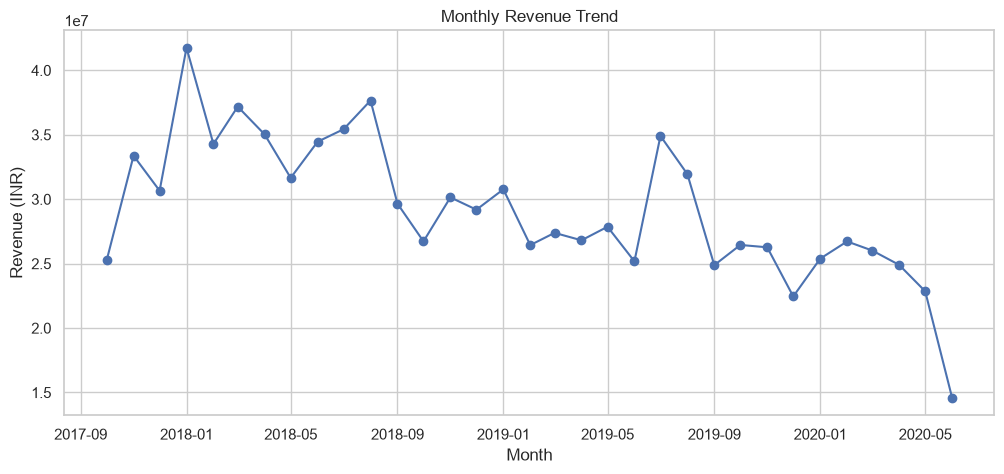

Revenue Volatility (Std Dev): 5,384,851.65
Coefficient of Variation: 0.1843


In [6]:
monthly_revenue = food_df.groupby(food_df['order_date'].dt.to_period('M'))['Sales_amount'].sum().reset_index()
monthly_revenue['order_date'] = monthly_revenue['order_date'].dt.to_timestamp()
monthly_revenue['Growth_%'] = monthly_revenue['Sales_amount'].pct_change() * 100

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['order_date'], monthly_revenue['Sales_amount'], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.show()

mean_rev = monthly_revenue['Sales_amount'].mean()
std_rev = monthly_revenue['Sales_amount'].std()
print(f"Revenue Volatility (Std Dev): {std_rev:,.2f}")
print(f"Coefficient of Variation: {std_rev / mean_rev:.4f}")

### Q2: Is Revenue Distribution Skewed?

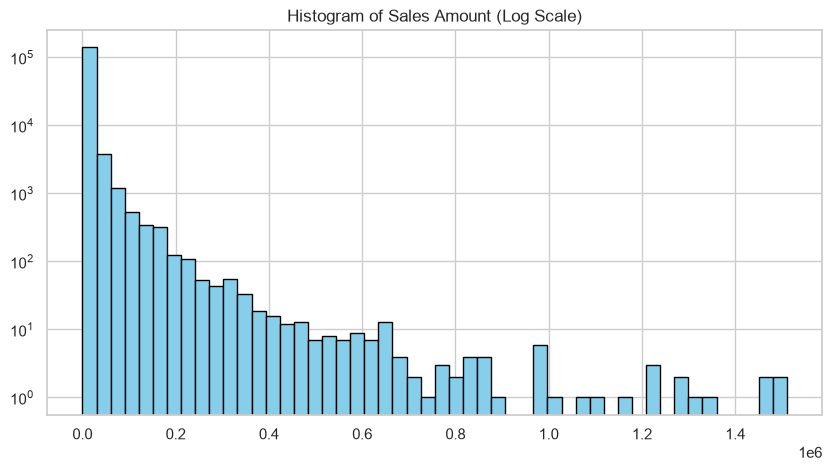

Skewness: 18.363586851483127
Kurtosis: 560.9714578568158


In [7]:
plt.figure(figsize=(10,5))
plt.hist(food_df['Sales_amount'], bins=50, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title("Histogram of Sales Amount (Log Scale)")
plt.show()

print("Skewness:", food_df['Sales_amount'].skew())
print("Kurtosis:", food_df['Sales_amount'].kurt())

### Q3: Which Cities Are Statistically Dominant?

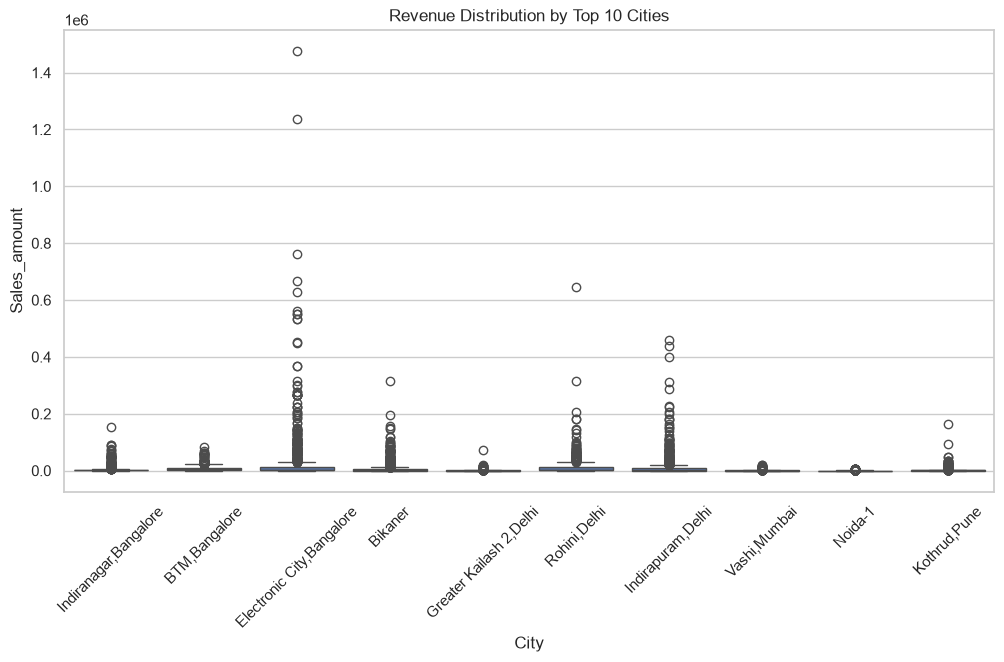

In [8]:
top_cities = food_df['City'].value_counts().head(10).index
df_top10 = food_df[food_df['City'].isin(top_cities)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top10, x='City', y='Sales_amount')
plt.xticks(rotation=45)
plt.title("Revenue Distribution by Top 10 Cities")
plt.show()

### Q4: What Is the Distribution of Customer Lifetime Value (CLV)?

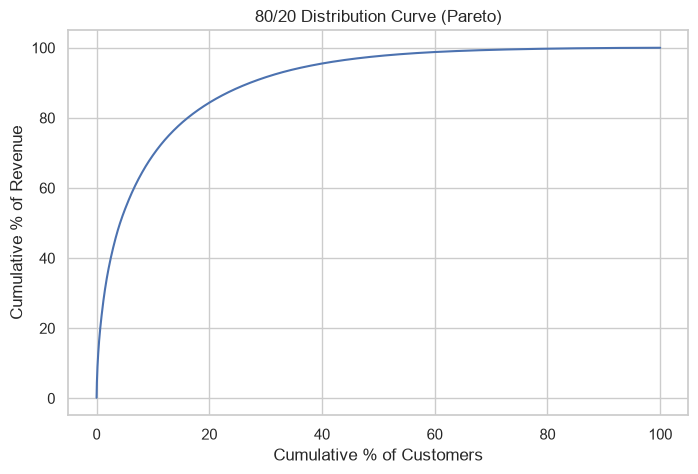

Mean CLV: 12484.744960186445
Median CLV: 1921.0


In [9]:
clv = food_df.groupby('User_id')['Sales_amount'].sum().reset_index().rename(columns={'Sales_amount':'CLV'})
clv_sorted = clv.sort_values(by='CLV', ascending=False)
clv_sorted['cum_revenue_pct'] = clv_sorted['CLV'].cumsum() / clv_sorted['CLV'].sum() * 100
clv_sorted['cum_customers_pct'] = np.arange(1, len(clv_sorted)+1) / len(clv_sorted) * 100

plt.figure(figsize=(8,5))
plt.plot(clv_sorted['cum_customers_pct'], clv_sorted['cum_revenue_pct'])
plt.title("80/20 Distribution Curve (Pareto)")
plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.grid(True)
plt.show()

print("Mean CLV:", clv['CLV'].mean())
print("Median CLV:", clv['CLV'].median())

### Q5 & Q6: Age vs Spending & Ratings vs Revenue

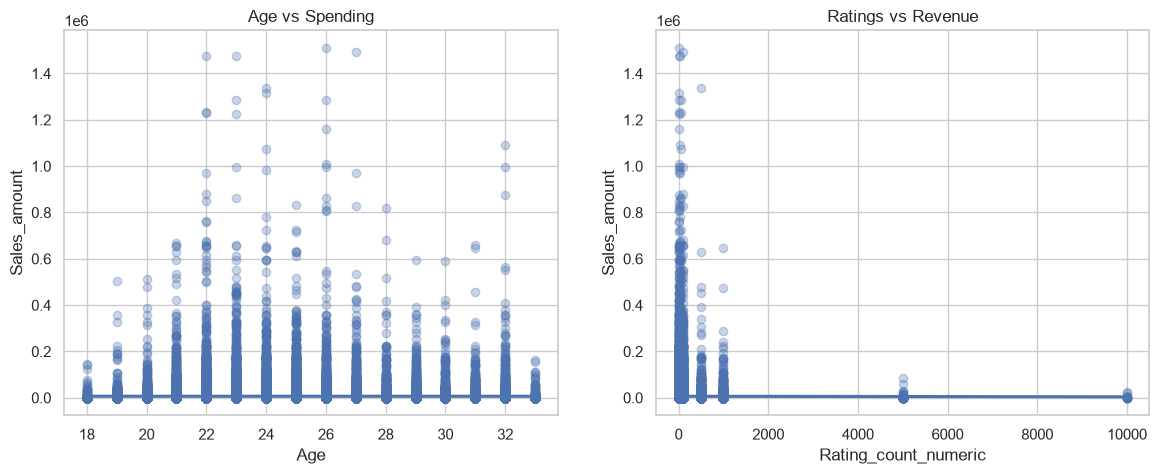

Age Correlation: -0.0007446018084714466
Ratings Correlation: -0.001904798758393512


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.regplot(x='Age', y='Sales_amount', data=food_df, scatter_kws={'alpha':0.3}, ax=axes[0])
axes[0].set_title("Age vs Spending")

sns.regplot(x='Rating_count_numeric', y='Sales_amount', data=food_df, scatter_kws={'alpha':0.3}, ax=axes[1])
axes[1].set_title("Ratings vs Revenue")
plt.show()

print("Age Correlation:", food_df[['Age','Sales_amount']].corr().iloc[0,1])
print("Ratings Correlation:", food_df[['Rating_count_numeric','Sales_amount']].corr().iloc[0,1])

### Q7 & Q8: Order Frequency & Recency vs Revenue

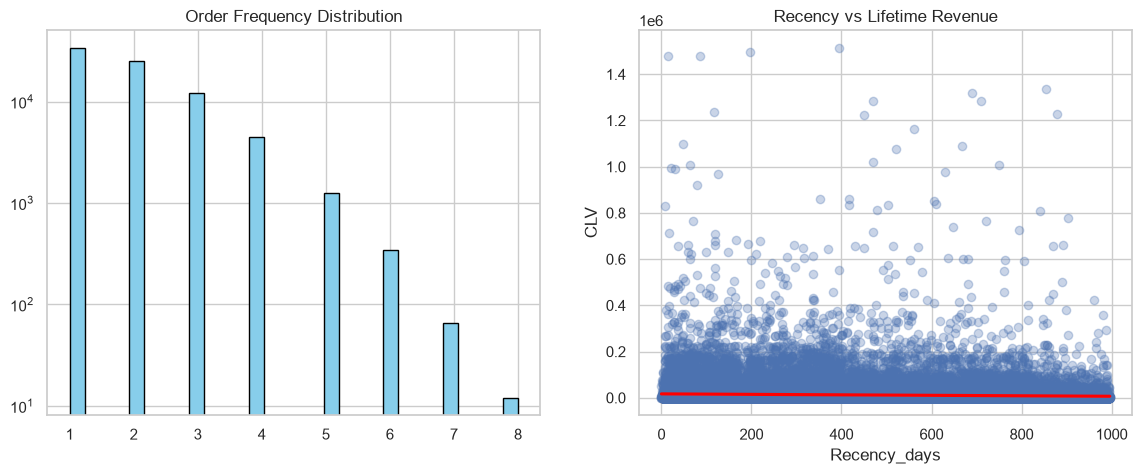

In [11]:
order_freq = food_df.groupby('User_id')['order_date'].count().reset_index().rename(columns={'order_date':'Order_Count'})
max_date = food_df['order_date'].max()

last_order = food_df.groupby('User_id')['order_date'].max().reset_index()
last_order['Recency_days'] = (max_date - last_order['order_date']).dt.days

recency_revenue = pd.merge(last_order[['User_id','Recency_days']], clv, on='User_id')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(order_freq['Order_Count'], bins=30, color='skyblue', edgecolor='black', log=True)
axes[0].set_title("Order Frequency Distribution")

sns.regplot(x='Recency_days', y='CLV', data=recency_revenue, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title("Recency vs Lifetime Revenue")
plt.show()

## 7. Advanced Statistical & Churn Analysis

### Q9 & Q10: Active vs Churned Profiling (T-Tests)

In [12]:
ref_date = food_df['order_date'].max()
cutoff_date = ref_date - pd.Timedelta(days=90)

user_features = food_df.groupby('User_id').agg(
    total_orders = ('order_date', 'count'),
    total_revenue = ('Sales_amount', 'sum'),
    first_order_date = ('order_date', 'min'),
    last_order_date = ('order_date', 'max')
).reset_index()

user_features['recency'] = (ref_date - user_features['last_order_date']).dt.days
user_features['active_days'] = (user_features['last_order_date'] - user_features['first_order_date']).dt.days
user_features['avg_order_value'] = user_features['total_revenue'] / user_features['total_orders']
user_features['churn'] = (user_features['last_order_date'] < cutoff_date).astype(int)

display(user_features.groupby('churn')[['total_orders', 'total_revenue', 'recency', 'avg_order_value']].mean())

t_orders = ttest_ind(user_features[user_features['churn']==1]['total_orders'], user_features[user_features['churn']==0]['total_orders'])
t_revenue = ttest_ind(user_features[user_features['churn']==1]['total_revenue'], user_features[user_features['churn']==0]['total_revenue'])

print(f"Orders T-test p-value: {t_orders.pvalue}")
print(f"Revenue T-test p-value: {t_revenue.pvalue}")

,total_orders,total_revenue,recency,avg_order_value
churn,,,,
0,2.410278,16414.495612,44.626309,6716.106699
1,1.833471,11936.430582,470.792617,6442.915342


Orders T-test p-value: 0.0
Revenue T-test p-value: 1.5149127457260511e-22


### Q11 & Q12: Feature Importance & RFM Segmentation

Correlations with Churn:
total_orders      -0.183812
total_revenue     -0.035145
recency            0.512637
avg_order_value   -0.003908
churn              1.000000
Name: churn, dtype: float64


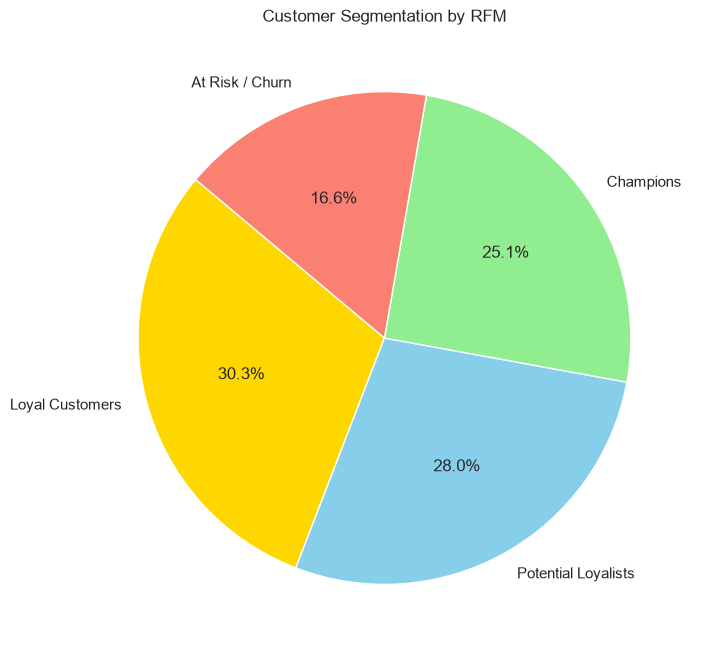

In [13]:
print("Correlations with Churn:")
print(user_features[['total_orders','total_revenue','recency','avg_order_value','churn']].corr()['churn'])

# RFM Scoring
user_features['R_score'] = pd.qcut(user_features['recency'], 5, labels=[5,4,3,2,1]).astype(int)
user_features['F_score'] = pd.qcut(user_features['total_orders'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
user_features['M_score'] = pd.qcut(user_features['total_revenue'], 5, labels=[1,2,3,4,5]).astype(int)
user_features['RFM_Score'] = user_features['R_score'] + user_features['F_score'] + user_features['M_score']

def segment(x):
    if x >= 12: return 'Champions'
    elif x >= 9: return 'Loyal Customers'
    elif x >= 6: return 'Potential Loyalists'
    else: return 'At Risk / Churn'

user_features['Segment'] = user_features['RFM_Score'].apply(segment)
segment_counts = user_features['Segment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=['gold','skyblue','lightgreen','salmon'])
plt.title("Customer Segmentation by RFM")
plt.show()

### Q13 & Q14: Overall Churn Rate & Outliers

In [14]:
churn_rate = user_features['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Q1 = food_df['Sales_amount'].quantile(0.25)
Q3 = food_df['Sales_amount'].quantile(0.75)
IQR = Q3 - Q1
outliers = food_df[(food_df['Sales_amount'] < Q1 - 1.5*IQR) | (food_df['Sales_amount'] > Q3 + 1.5*IQR)]
print(f"Outliers detected: {outliers.shape[0]}")

Overall Churn Rate: 87.76%
Outliers detected: 21988


## 8. Machine Learning Pipeline

### Data Preparation
**Important:** We exclude `recency` from the ML features to prevent data leakage, as `churn` was strictly defined by `recency > 90`. We also add `active_days` (lifespan) to capture historical engagement duration.

In [15]:
from sklearn.model_selection import GridSearchCV
user_features = user_features.merge(users[['User_id', 'Age', 'Gender']], on='User_id', how='left')
user_features['Age'] = user_features['Age'].fillna(user_features['Age'].median())
user_features = pd.get_dummies(user_features, columns=['Gender'], drop_first=True)

# Drop leakages and identifiers
X = user_features.drop(columns=['User_id', 'first_order_date', 'last_order_date', 'churn', 'recency', 'Segment', 'R_score', 'F_score', 'M_score', 'RFM_Score'])
y = user_features['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Multi-Model Training & Hyperparameter Optimization

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Optimized Random Forest via GridSearchCV
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42, scale_pos_weight=7)
xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("Best RF Parameters:", rf_grid.best_params_)
print("\nOptimized Random Forest Evaluation:")
print(classification_report(y_test, rf_pred))
print("Optimized Random Forest ROC AUC:", roc_auc_score(y_test, rf_prob))
print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_prob))

### ROC Curve Comparison & Feature Importance

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {roc_auc_score(y_test, log_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Un-leaked Models)")
plt.legend(loc="lower right")
plt.show()

# RF Feature Importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_importance.plot(kind='barh', figsize=(8,5), color='skyblue')
plt.title("Random Forest Feature Importance")
plt.show()

## 9. Export for Deployment

In [ ]:
# Save KPIs
kpis = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Orders', 'Overall Churn Rate'],
    'Value': [food_df['Sales_amount'].sum(), len(orders), churn_rate]
})
kpis.to_csv('Processed_Data/kpi_summary.csv', index=False)

# Export processed datasets
user_features.to_csv('Processed_Data/processed_users_rfm.csv', index=False)
food_df.to_csv('Processed_Data/processed_orders.csv', index=False)

# Save the best model (Random Forest)
joblib.dump(rf_model, 'Processed_Data/best_churn_model.pkl')
joblib.dump(scaler, 'Processed_Data/scaler.pkl')

print("Assets successfully exported to Processed_Data/")